# 🛡 AI-Driven Fraud Detection — UWS MSc Project
**Student:** Evans Polley | **Banner ID:** B01823633  
**University of the West of Scotland** — School of Computing, Engineering and Physical Sciences

---
## Instructions
1. Upload your 4 CSV files to `/content/` in the Files panel (left sidebar)
2. Run all cells in order (`Runtime → Run all`)
3. All metrics, charts, and the merged dataset will be displayed inline

**Expected files:**
- `/content/fraudTrain.csv`
- `/content/fraudTest.csv`
- `/content/df_2026-03-10 05_53_16.csv`  *(or similar name)*
- `/content/creditcard.csv`

In [1]:
# ═══════════════════════════════════════════════════════
# CELL 1 — Install dependencies
# ═══════════════════════════════════════════════════════
!pip install imbalanced-learn scikit-learn pandas numpy matplotlib openpyxl -q
print('✅ Dependencies installed')

✅ Dependencies installed


In [2]:
# ═══════════════════════════════════════════════════════
# CELL 2 — Upload fraud_pipeline.py
# ═══════════════════════════════════════════════════════
# Verify the file exists
import os
if os.path.exists('fraud_pipeline.py'):
    print('✅ fraud_pipeline.py found')
else:
    print('❌ Upload fraud_pipeline.py first (File → Upload to session storage)')

✅ fraud_pipeline.py found


In [3]:
# ═══════════════════════════════════════════════════════
# CELL 3 — Load all 4 CSV files
# ═══════════════════════════════════════════════════════
import glob, os
from fraud_pipeline import FraudDataPipeline, ModelManager

# Auto-discover CSV files in /content/
all_csvs = sorted(glob.glob('/content/*.csv'))
print('Found CSV files:')
for f in all_csvs:
    size_mb = os.path.getsize(f) / 1e6
    print(f'  {f}  ({size_mb:.1f} MB)')

# Initialise pipeline and load all files
pipeline = FraudDataPipeline()
df = pipeline.load_all(all_csvs)

# Print the load + merge report
pipeline.print_report()

# Source breakdown
print('Records per source:')
print(pipeline.get_source_summary().to_string(index=False))

Found CSV files:
  /content/creditcard.csv  (5.2 MB)
  /content/df_2026-03-10 05_53_16.csv  (2.1 MB)
  /content/fraudTest.csv  (5.2 MB)
  /content/fraudTrain.csv  (5.2 MB)

  FRAUD PIPELINE — LOAD & MERGE REPORT
  OK  creditcard.csv                             schema=creditcard     rows=    9,965  fraud=     38 (0.381%)
  OK  df_2026-03-10 05_53_16.csv                 schema=transactions   rows=   10,000  fraud=    102 (1.020%)
  OK  fraudTest.csv                              schema=transactions   rows=   19,466  fraud=     68 (0.349%)
  OK  fraudTrain.csv                             schema=transactions   rows=   19,476  fraud=    132 (0.678%)
  
MERGED: 55,051 total rows  (3,856 duplicates removed)  |  Fraud: 318 (0.5777%)

Records per source:
   source_tag  total  fraud  legit fraud_pct
creditcard_eu   9755     38   9717    0.390%
   fraud_test  19465     68  19397    0.349%
  fraud_train  15828    110  15718    0.695%
  sample_data  10000    102   9898    1.020%


In [4]:
# ═══════════════════════════════════════════════════════
# CELL 4 — Dataset overview
# ═══════════════════════════════════════════════════════
import pandas as pd

print(f'Total rows:    {len(df):,}')
print(f'Features:      {len(pipeline.feature_names)}')
print(f'Fraud records: {int(df["is_fraud"].sum()):,}  ({df["is_fraud"].mean()*100:.4f}%)')
print(f'Legit records: {int((df["is_fraud"]==0).sum()):,}')
print()
print('Sample rows:')
display(df[['source_tag','amt','trans_hour','age','geo_distance',
             'is_online','amt_zscore','is_fraud']].head(10))

Total rows:    55,051
Features:      52
Fraud records: 318  (0.5777%)
Legit records: 54,730

Sample rows:


,source_tag,amt,trans_hour,age,geo_distance,is_online,amt_zscore,is_fraud
0,fraud_test,50.25,9.0,34.579055,0.260914,1.0,-0.133086,0.0
1,fraud_train,104.59,18.0,37.341547,0.722730,1.0,0.226764,0.0
2,fraud_test,5.94,23.0,63.989049,0.793746,0.0,-0.450997,0.0
3,fraud_test,26.88,15.0,25.377139,0.433705,0.0,-0.300759,0.0
4,fraud_test,55.03,14.0,42.847365,0.615161,0.0,-0.098792,0.0
5,fraud_train,91.33,10.0,59.961670,0.177784,0.0,0.138517,0.0
6,fraud_test,9.62,8.0,68.369610,0.765511,0.0,-0.424594,0.0
7,fraud_train,16.71,20.0,73.368925,0.528563,0.0,-0.358086,0.0
8,fraud_test,84.06,21.0,43.033539,1.110415,0.0,0.109489,0.0
9,fraud_test,31.36,3.0,25.122519,0.648296,0.0,-0.268616,0.0


In [5]:
# ═══════════════════════════════════════════════════════
# CELL 5 — Train / Test split + SMOTE
# ═══════════════════════════════════════════════════════
pipeline.split_and_resample(test_size=0.2, use_smote=True)

print(f'Training set:  {pipeline.X_train.shape}  |  fraud: {pipeline.y_train.sum():,}')
print(f'Test set:      {pipeline.X_test.shape}   |  fraud: {pipeline.y_test.sum():,}')

Training set:  (87568, 52)  |  fraud: 43,784
Test set:      (11010, 52)   |  fraud: 64


In [6]:
# ═══════════════════════════════════════════════════════
# CELL 6 — Train all 4 models
# ═══════════════════════════════════════════════════════
mm = ModelManager()
results = mm.train_all(
    pipeline.X_train, pipeline.y_train,
    pipeline.X_test,  pipeline.y_test,
    progress_cb=print
)

print()
print(f'{"Model":<25} {"Accuracy":>9} {"Precision":>10} {"Recall":>8} {"F1":>8} {"AUC-ROC":>9}')
print('-' * 75)
for name, r in results.items():
    if 'f1' in r:
        print(f'{name:<25} {r["accuracy"]:>9.3f} {r["precision"]:>10.3f} '
              f'{r["recall"]:>8.3f} {r["f1"]:>8.3f} {r["auc"]:>9.3f}')
    elif 'error' in r:
        print(f'{name:<25}  ERROR: {r["error"]}')

Training Logistic Regression…
Training Decision Tree…
Training Random Forest…
Training SVM…

Model                      Accuracy  Precision   Recall       F1   AUC-ROC
---------------------------------------------------------------------------
Logistic Regression           0.882      0.042    0.891    0.081     0.954
Decision Tree                 0.975      0.167    0.812    0.277     0.868
Random Forest                 0.998      0.877    0.781    0.826     0.989
SVM                           0.973      0.150    0.781    0.252     0.923


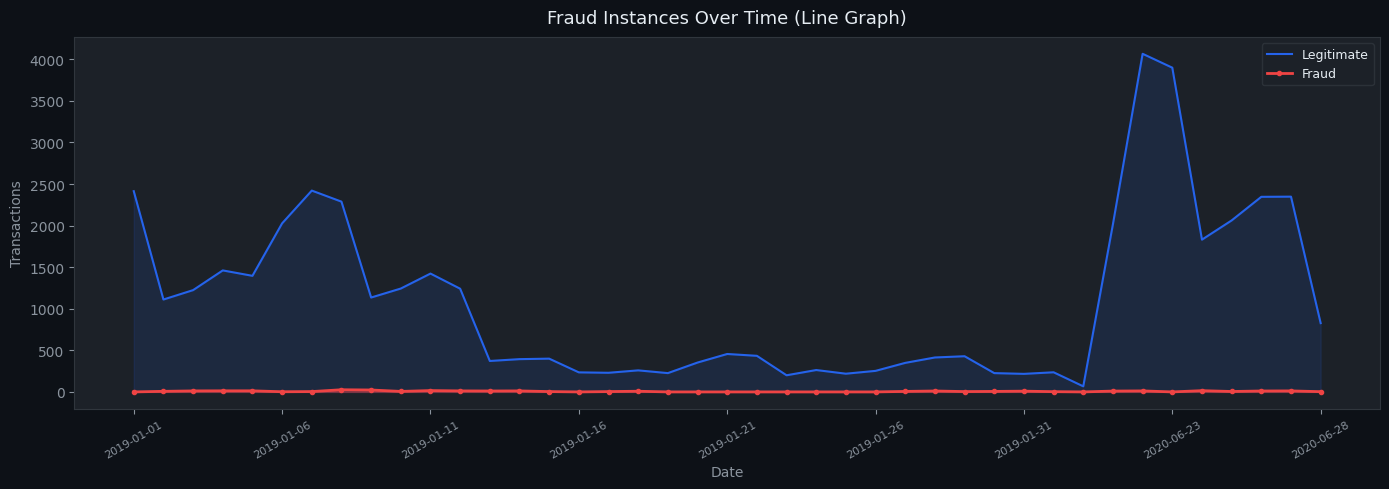

In [7]:
# ═══════════════════════════════════════════════════════
# CELL 7 — Chart 1: Fraud Over Time (Line Graph)
# ═══════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_facecolor('#1C2128'); fig.patch.set_facecolor('#0D1117')

# Use only rows that have real datetime (transactions schema)
dt_df = df[df['trans_datetime'].notna()].copy()
if len(dt_df) > 0:
    dt_df['date'] = pd.to_datetime(dt_df['trans_datetime'], utc=True, errors='coerce').dt.date
    daily = dt_df.groupby(['date','is_fraud']).size().unstack(fill_value=0)
    x = range(len(daily))
    if 0 in daily.columns:
        ax.plot(x, daily[0], color='#2563EB', lw=1.5, label='Legitimate')
        ax.fill_between(x, daily[0], alpha=0.12, color='#2563EB')
    if 1 in daily.columns:
        ax.plot(x, daily[1], color='#EF4444', lw=2, label='Fraud', marker='o', markersize=3)
        ax.fill_between(x, daily[1], alpha=0.35, color='#EF4444')
    step = max(1, len(daily)//8)
    ax.set_xticks(range(0, len(daily), step))
    ax.set_xticklabels([str(d) for d in daily.index[::step]], rotation=30,
                        fontsize=8, color='#8B949E')
else:
    ax.text(0.5, 0.5, 'No datetime data available (creditcard.csv only)',
            ha='center', va='center', color='#8B949E', transform=ax.transAxes, fontsize=12)

ax.set_title('Fraud Instances Over Time (Line Graph)', color='#E6EDF3', fontsize=13, pad=10)
ax.set_xlabel('Date', color='#8B949E'); ax.set_ylabel('Transactions', color='#8B949E')
ax.tick_params(colors='#8B949E')
for sp in ax.spines.values(): sp.set_color('#30363D')
ax.legend(facecolor='#1C2128', edgecolor='#30363D', labelcolor='#E6EDF3', fontsize=9)
plt.tight_layout(); plt.show()

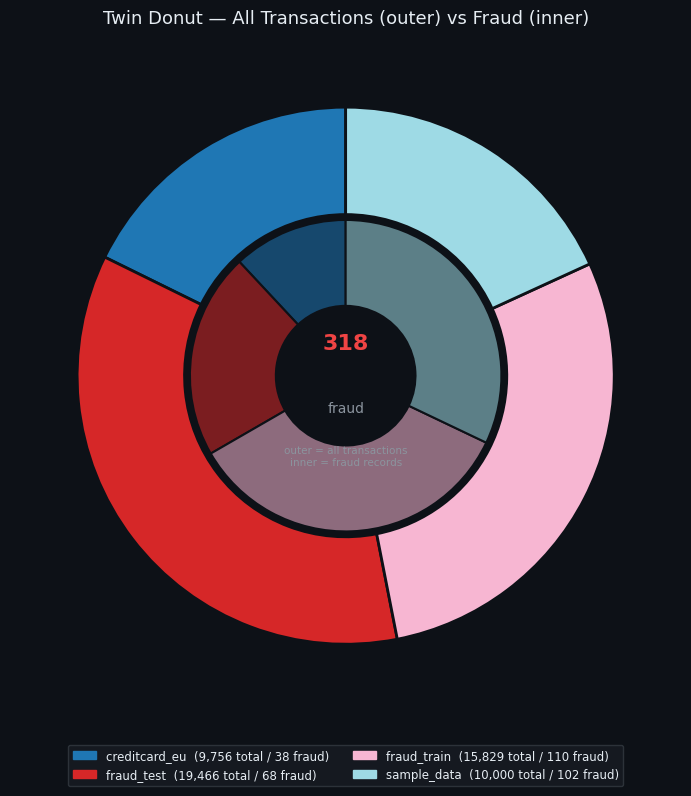

In [8]:
# ═══════════════════════════════════════════════════════
# CELL 8 — Chart 2: Twin Donut (All Transactions vs Fraud)
# ═══════════════════════════════════════════════════════
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0D1117'); ax.set_facecolor('#0D1117')

# Use source_tag as the grouping dimension (works for ALL files)
cat_totals = df.groupby('source_tag').size()
cat_fraud  = df[df['is_fraud']==1].groupby('source_tag').size().reindex(cat_totals.index, fill_value=0)
labels     = cat_totals.index.tolist()

cmap    = plt.cm.get_cmap('tab20', max(len(labels), 2))
colours = [cmap(i) for i in range(len(labels))]
fraud_c = [(*c[:3], 0.55) for c in colours]

# Outer ring — all transactions by source
ax.pie(cat_totals.values, radius=1.0, colors=colours, startangle=90,
       wedgeprops=dict(width=0.40, edgecolor='#0D1117', linewidth=2))

# Inner ring — fraud only by source
if cat_fraud.sum() > 0:
    ax.pie(cat_fraud.values, radius=0.58, colors=fraud_c, startangle=90,
           wedgeprops=dict(width=0.32, edgecolor='#0D1117', linewidth=1.5))

# Centre annotations
ft = int(cat_fraud.sum())
ax.text(0,  0.12, f'{ft:,}',    ha='center', va='center',
        fontsize=16, fontweight='bold', color='#EF4444')
ax.text(0, -0.12, 'fraud',      ha='center', va='center',
        fontsize=10, color='#8B949E')
ax.text(0, -0.30, 'outer = all transactions\ninner = fraud records',
        ha='center', va='center', fontsize=7.5, color='#8B949E')

# Legend with counts
legend_labels = [
    f"{labels[i]}  ({cat_totals.values[i]:,} total / {cat_fraud.values[i]:,} fraud)"
    for i in range(len(labels))
]
patches = [mpatches.Patch(color=colours[i], label=legend_labels[i])
           for i in range(len(labels))]
ax.legend(handles=patches, loc='lower center', bbox_to_anchor=(0.5, -0.12),
          ncol=2, fontsize=8.5, facecolor='#161B22',
          edgecolor='#30363D', labelcolor='#E6EDF3', framealpha=0.9)

ax.set_title('Twin Donut — All Transactions (outer) vs Fraud (inner)',
             color='#E6EDF3', fontsize=13, pad=12)
plt.tight_layout(); plt.show()

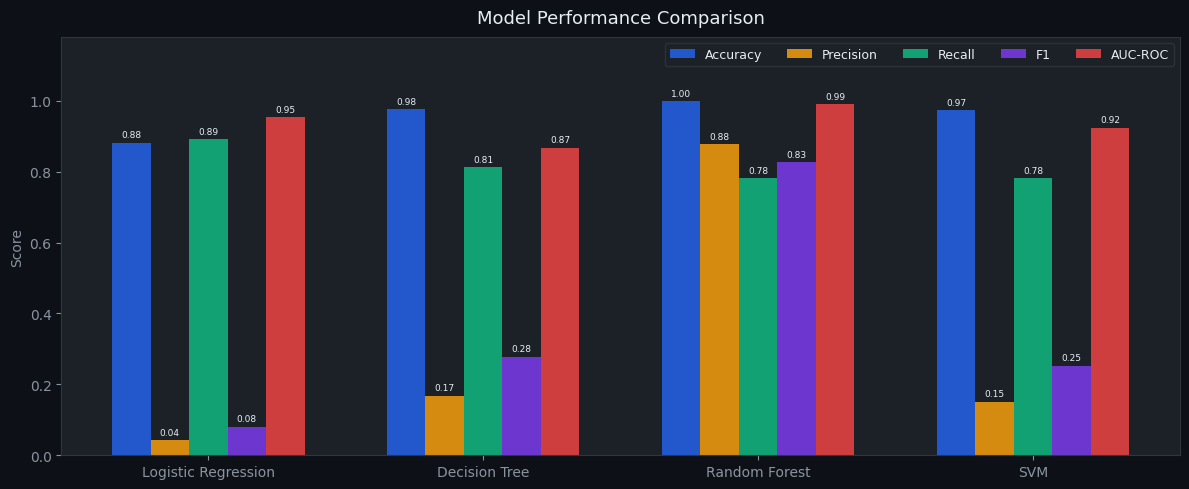

In [9]:
# ═══════════════════════════════════════════════════════
# CELL 9 — Chart 3: Model Metrics Comparison (Bar)
# ═══════════════════════════════════════════════════════
valid = {k: v for k, v in results.items() if 'f1' in v}
metrics  = ['accuracy','precision','recall','f1','auc']
m_labels = ['Accuracy','Precision','Recall','F1','AUC-ROC']
colours  = ['#2563EB','#F59E0B','#10B981','#7C3AED','#EF4444']

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_facecolor('#1C2128'); fig.patch.set_facecolor('#0D1117')

x = np.arange(len(valid)); w = 0.14
for i, (metric, col, lbl) in enumerate(zip(metrics, colours, m_labels)):
    vals = [v.get(metric, 0) for v in valid.values()]
    bars = ax.bar(x + i*w, vals, w, label=lbl, color=col, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom',
                fontsize=6.5, color='#E6EDF3')

ax.set_xticks(x + w*2)
ax.set_xticklabels(list(valid.keys()), fontsize=10, color='#E6EDF3')
ax.set_ylim(0, 1.18)
ax.set_title('Model Performance Comparison', color='#E6EDF3', fontsize=13, pad=10)
ax.set_ylabel('Score', color='#8B949E')
ax.tick_params(colors='#8B949E')
for sp in ax.spines.values(): sp.set_color('#30363D')
ax.legend(facecolor='#1C2128', edgecolor='#30363D',
          labelcolor='#E6EDF3', fontsize=9, ncol=5)
plt.tight_layout(); plt.show()

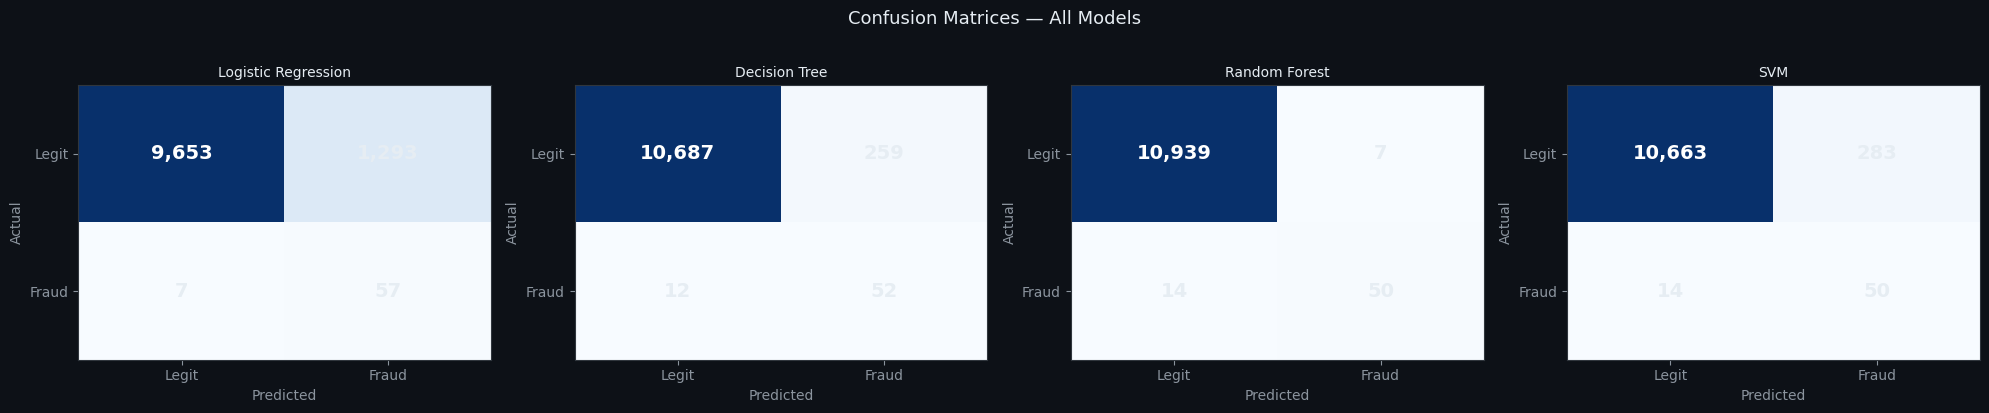

In [10]:
# ═══════════════════════════════════════════════════════
# CELL 10 — Chart 4: Confusion Matrices (all models)
# ═══════════════════════════════════════════════════════
valid = {k: v for k, v in results.items() if 'cm' in v}
n = len(valid)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
fig.patch.set_facecolor('#0D1117')
if n == 1: axes = [axes]

for ax, (mname, res) in zip(axes, valid.items()):
    cm = res['cm']
    ax.set_facecolor('#1C2128')
    ax.imshow(cm, cmap='Blues', aspect='auto')
    ax.set_title(mname, color='#E6EDF3', fontsize=10, pad=6)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Legit','Fraud'], color='#8B949E')
    ax.set_yticklabels(['Legit','Fraud'], color='#8B949E')
    ax.set_xlabel('Predicted', color='#8B949E')
    ax.set_ylabel('Actual', color='#8B949E')
    ax.tick_params(colors='#8B949E')
    for sp in ax.spines.values(): sp.set_color('#30363D')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if cm[i,j] > cm.max()/2 else '#E6EDF3')

plt.suptitle('Confusion Matrices — All Models', color='#E6EDF3', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

In [11]:
# ═══════════════════════════════════════════════════════
# CELL 11 — Export merged dataset & results
# ═══════════════════════════════════════════════════════
from google.colab import files

# Save merged dataset
df.to_csv('merged_fraud_dataset.csv', index=False)

# Save metrics summary
import json
summary = {
    name: {k: float(v) for k, v in r.items()
           if k in ['accuracy','precision','recall','f1','auc']}
    for name, r in results.items() if 'f1' in r
}
with open('model_results.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Files saved:')
print('  merged_fraud_dataset.csv')
print('  model_results.json')
print()
print('Downloading...')
files.download('merged_fraud_dataset.csv')
files.download('model_results.json')

Files saved:
  merged_fraud_dataset.csv
  model_results.json

Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>